In [1]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [2]:
from tensornetworkrg.tnrg import TensorNetworkRG2D

# (1 Dec 2025) Stability of the ordered-phase (SSB) fixed point for the positive-$z$ transition

SSB of the lattice symmetries, like rotation, happens when the acitivty $z$ increases from 0 and crosses the critical value $z_c^+$;
the best estimate is
$$
z_c^+ = 3.79625517391234(4).
$$

In [3]:
zc = 3.79625517391234

The stability of the SSB fixed point depends on whether the RG map preserves these lattice symmetries.
If an RG map breaks lattice symmetires more severely than the other, the SSB fixed point becomes less stable.
In order to demonstrate this, we will compared RG flows generated by the TRG and the HOTRG.
The HOTRG breaks the lattice rotation symmetry more than the TRG.

We will generate RG flows at the following values of activity:

In [4]:
# zTry = [2.0, 3.0, 3.7, zc, 4.0, 6.0, 9.0]
# zTry = [3.0, 3.7, zc, 4.0, 6.0]
zTry = [6.0, 4.7, zc, 3.7, 3.0]

## I. A single-number characterization of the tensor RG flow

To visualize the tensor RG flow, we define a single-number characterization of the phase a tensor $A$ represents a la Gu and Wen in their 2009 paper.
We first obtain the transfer matrix $T$ from this tensor $A$ (and also the bond matrix $\sigma$);
then, the following *degeneracy index* is defined from the eigenvalues $\{\lambda_k\}$ of the transfer matrix $T$:
$$
X = \frac{(\sum_k |\lambda_k|)^2}{\sum_k |\lambda_k|^2}.
$$
In the thermodynamical limit, suppose the eigenvalue spectrum has $n$-fold degeneracy, while all other smaller eigenvalues can be neglected, then this degeneracy index takes value
$$
X = \frac{(n |\lambda_{max}|)^2}{n |\lambda_{max}|^2} = n,
$$
which is why we call it degeneracy index.

## II. RG flows generated by the HOTRG ($\chi=10$)

In [5]:
scheme = "hotrg"
ver = "general"
chi = 10
dtol = 1e-10
rgpars = {"chi": chi, "dtol": dtol, "display": False}
rg_n = 17
Xdata = []
for z in zTry:
    hdsq1NN = TensorNetworkRG2D("hardsquare1NN")
    hdsq1NN.model_parameters = {"activity": z}
    hdsq1NN.generate_initial_tensor(scheme="trg")
    Xflow = []
    for k in range(rg_n):
        lrerr, SPerrs = hdsq1NN.rgmap(rgpars, scheme=scheme, ver=ver)
        curX = hdsq1NN.degIndX()
        Xflow.append(curX)
    Xdata.append(Xflow)

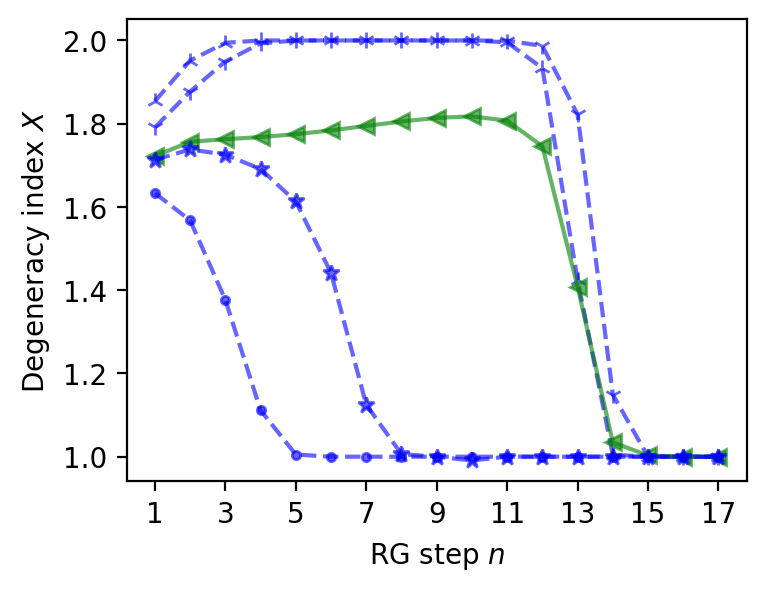

In [6]:
# marker = itertools.cycle(('.', '*', '<', '1', '2', '3', '4'))
marker = itertools.cycle(('2', '1', '<', '*', '.', '3', '4'))
plt.figure(figsize=(4,3))
rgnList = np.arange(rg_n) + 1
rgTicks = np.arange(rg_n, step=2) + 1
for z, Xflow in zip(zTry, Xdata):
    curmarker = next(marker)
    if z == zc:
        plt.plot(rgnList, Xflow, "g" + curmarker + "-", alpha=0.6,
                label=r"$z$={:.2f}".format(z))
    else:
        plt.plot(rgnList, Xflow, "b" + curmarker + "--", alpha=0.6,
                label=r"$z$={:.2f}".format(z))
    plt.ylabel("Degeneracy index $X$")
    plt.xlabel("RG step $n$")
#plt.hlines(1, 1, rg_n, color="k", linestyles='dashed')
#plt.hlines(2, 1, rg_n, color="k", linestyles='dashed')
#plt.title("RG flows generated by the HOTRG")
plt.xticks(rgTicks)
#plt.legend()
plt.savefig("model-zplusHOTRGflow.pdf",  bbox_inches='tight', dpi=200)
plt.show()

We see that for $z > z_c^+$, the tensor first flows to the SSB fixed point with $X=2$, but then flows away when RG step reaches $n \approx 11$.

## III. RG flows generated by the TRG ($\chi=10$)

In [7]:
scheme = "trg"
ver = "general"
chi = 10
dtol = 1e-10
rgpars = {"chi": chi, "dtol": dtol, "display": False}
rg_n = 31
Xdata = []
for z in zTry:
    hdsq1NN = TensorNetworkRG2D("hardsquare1NN")
    hdsq1NN.model_parameters = {"activity": z}
    hdsq1NN.generate_initial_tensor(scheme="trg")
    Xflow = []
    for k in range(rg_n):
        lrerr, SPerrs = hdsq1NN.rgmap(rgpars, scheme=scheme, ver=ver)
        curX = hdsq1NN.degIndX()
        Xflow.append(curX)
    Xdata.append(Xflow)

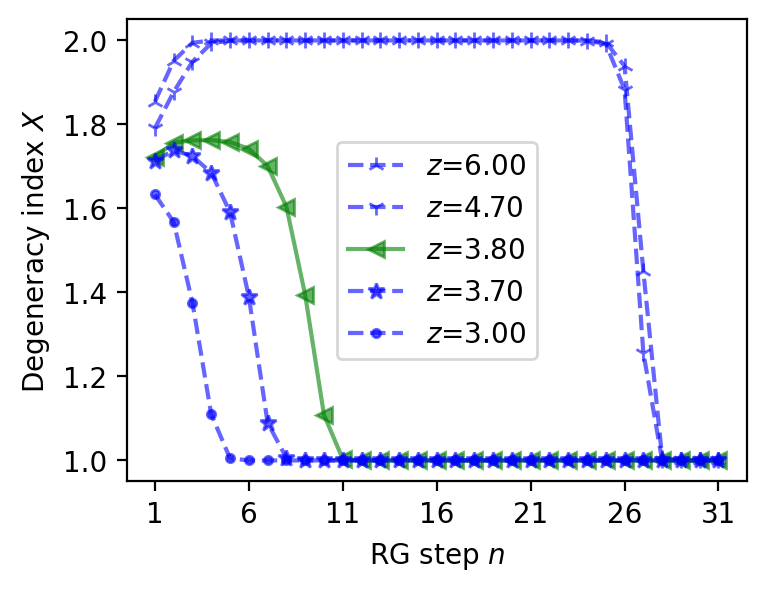

In [8]:
# marker = itertools.cycle(('.', '*', '<', '1', '2', '3', '4'))
marker = itertools.cycle(('2', '1', '<', '*', '.', '3', '4'))
plt.figure(figsize=(4,3))
rgnList = np.arange(rg_n) + 1
rgTicks = np.arange(rg_n, step=5) + 1
for z, Xflow in zip(zTry, Xdata):
    curmarker = next(marker)
    if z == zc:
        plt.plot(rgnList, Xflow, "g" + curmarker + "-", alpha=0.6,
                label=r"$z$={:.2f}".format(z))
    else:
        plt.plot(rgnList, Xflow, "b" + curmarker + "--", alpha=0.6,
                label=r"$z$={:.2f}".format(z))
    plt.ylabel("Degeneracy index $X$")
    plt.xlabel("RG step $n$")

#plt.hlines(1, 1, rg_n, color="k", linestyles='dashed')
#plt.hlines(2, 1, rg_n, color="k", linestyles='dashed')
#plt.title("RG flows generated by the TRG")
plt.xticks(rgTicks)
plt.legend()
plt.savefig("model-zplusTRGflow.pdf",  bbox_inches='tight', dpi=200)
plt.show()

We see that for $z > z_c^+$, the tensor first flows to the SSB fixed point with $X=2$, but then flows away when RG step reaches $n \approx 26$.

For the positive-$z$ transition, we have demonstrated that the extent to which a TNRG scheme preserves the lattice-rotation symmetry affects the stability of the SSB fixed point.